# Terraces Semantic Segmentation - SegFormer (MiT-B3)

Binary semantic segmentation of building terraces from aerial orthophotos.
The encoder is a Mix Transformer (MiT-B3) pretrained on ImageNet, wrapped in the
SegFormer decoder from `segmentation_models_pytorch`.

**Pipeline:** 512x512 GeoTIFF tiles -> filter by size -> 80/20 split -> Dice+BCE training with AMP -> best-IoU checkpoint -> geo-referenced inference on unseen tiles.

Predicted masks preserve the CRS and affine transform of the input tile, so they align with the source imagery in QGIS.

> **Data note:** the aerial tiles and hand-labelled masks are internship data and are not included in this repository. Set `MAP_DIR`, `MASK_DIR` and `UNSEEN_TILES_DIR` in the config cell to point at your own dataset before running.

## Cell 1 — Install dependencies 

In [4]:
# !pip install -q rasterio segmentation-models-pytorch albumentations timm tqdm scikit-learn matplotlib
# !pip install -q torch torchvision  
print("All libraries downloaded")

All libraries downloaded


## Cell 2 — Imports & Configuration

In [5]:
import os
import random
import shutil
import warnings
from glob import glob

import numpy as np
import rasterio
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

MAP_DIR  = "Final Dataset/map"          # original map tiles (map_00001.tif ...)
MASK_DIR = "Final Dataset/mask"         # original mask tiles (mask_00001.tif ...)
OUTPUT_DIR = "segformer_output"     # split data + checkpoints will be written here

# folder of unseen tiles you will predict on later
UNSEEN_TILES_DIR = "New Tiles"
PREDICTIONS_DIR  = "segformer_prediction"
# ============================================================

# Hyper-parameters (already tuned)
SEED            = 42
TILE_SIZE       = 512
BATCH_SIZE      = 4         
NUM_EPOCHS      = 60
LEARNING_RATE   = 6e-5       # standard for SegFormer fine-tune
WEIGHT_DECAY    = 1e-4
NUM_WORKERS     = 4
ENCODER_NAME    = "mit_b3"
ENCODER_WEIGHTS = "imagenet"
NUM_CLASSES     = 1          # binary (terrace / not terrace)
THRESHOLD       = 0.5        # sigmoid -> binary mask

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU:    {torch.cuda.get_device_name(0)}")

Device: cuda
GPU:    NVIDIA RTX 6000 Ada Generation


## Cell 3 — Filter tiles that are not 512×512

In [6]:
def filter_tiles_by_size(map_dir: str, mask_dir: str, target: int = 512) -> int:
    """Delete map/mask tiles whose dimensions != target. Keeps pairs synchronized."""
    map_files = sorted(glob(os.path.join(map_dir, "*.tif")))
    deleted, valid = 0, 0

    for map_path in tqdm(map_files, desc="Filtering tiles"):
        mask_path = os.path.join(mask_dir, os.path.basename(map_path).replace("map_", "mask_"))
        bad = False

        # check map
        try:
            with rasterio.open(map_path) as src:
                if src.width != target or src.height != target:
                    bad = True
        except Exception as e:
            print(f"  cannot read {map_path}: {e}")
            bad = True

        # check mask (must exist AND be correct size)
        if not os.path.exists(mask_path):
            bad = True
        elif not bad:
            try:
                with rasterio.open(mask_path) as src:
                    if src.width != target or src.height != target:
                        bad = True
            except Exception as e:
                print(f"  cannot read {mask_path}: {e}")
                bad = True

        if bad:
            for p in (map_path, mask_path):
                if os.path.exists(p):
                    os.remove(p)
            deleted += 1
        else:
            valid += 1

    print(f"\nValid pairs kept: {valid}")
    print(f"Pairs deleted:   {deleted}")
    return valid


valid_count = filter_tiles_by_size(MAP_DIR, MASK_DIR, TILE_SIZE)
assert valid_count > 0, "No valid 512x512 tiles found — check your paths."

Filtering tiles:   0%|          | 0/985 [00:00<?, ?it/s]


Valid pairs kept: 984
Pairs deleted:   1


## Cell 4 — Random 80/20 train/val split into folders

In [7]:
def split_dataset(map_dir: str, mask_dir: str, out_dir: str,
                  val_ratio: float = 0.2, seed: int = 42):
    """Copy tiles into out_dir/{train,val}/{map,mask}. Returns the four paths."""
    paths = {
        ("train", "map"):  os.path.join(out_dir, "train", "map"),
        ("train", "mask"): os.path.join(out_dir, "train", "mask"),
        ("val",   "map"):  os.path.join(out_dir, "val",   "map"),
        ("val",   "mask"): os.path.join(out_dir, "val",   "mask"),
    }
    for p in paths.values():
        # wipe previous split (idempotent re-runs)
        if os.path.isdir(p):
            shutil.rmtree(p)
        os.makedirs(p, exist_ok=True)

    map_files = sorted(glob(os.path.join(map_dir, "*.tif")))
    pairs = []
    for mp in map_files:
        mk = os.path.join(mask_dir, os.path.basename(mp).replace("map_", "mask_"))
        if os.path.exists(mk):
            pairs.append((mp, mk))

    train_pairs, val_pairs = train_test_split(pairs, test_size=val_ratio, random_state=seed)
    print(f"Train: {len(train_pairs)}  |  Val: {len(val_pairs)}")

    for mp, mk in tqdm(train_pairs, desc="Copy train"):
        shutil.copy2(mp, os.path.join(paths[("train", "map")],  os.path.basename(mp)))
        shutil.copy2(mk, os.path.join(paths[("train", "mask")], os.path.basename(mk)))
    for mp, mk in tqdm(val_pairs, desc="Copy val"):
        shutil.copy2(mp, os.path.join(paths[("val", "map")],  os.path.basename(mp)))
        shutil.copy2(mk, os.path.join(paths[("val", "mask")], os.path.basename(mk)))

    return (paths[("train", "map")], paths[("train", "mask")],
            paths[("val",   "map")], paths[("val",   "mask")])


train_map_dir, train_mask_dir, val_map_dir, val_mask_dir = split_dataset(
    MAP_DIR, MASK_DIR, OUTPUT_DIR, val_ratio=0.2, seed=SEED
)

Train: 787  |  Val: 197


Copy train:   0%|          | 0/787 [00:00<?, ?it/s]

Copy val:   0%|          | 0/197 [00:00<?, ?it/s]

## Cell 5 — Dataset class & DataLoaders
Train aug: flips, 90° rotations, slight affine, brightness/contrast — appropriate for aerial imagery.

In [8]:
def read_tif(path: str) -> np.ndarray:
    """Read .tif with rasterio -> (C, H, W) numpy array."""
    with rasterio.open(path) as src:
        return src.read()


def prepare_image(img_chw: np.ndarray) -> np.ndarray:
    """(C,H,W) -> (H,W,3) uint8."""
    img = np.transpose(img_chw, (1, 2, 0))            # HWC
    if img.shape[2] >= 4:                              # drop alpha / extra bands
        img = img[:, :, :3]
    elif img.shape[2] == 1:                            # grayscale -> 3ch
        img = np.repeat(img, 3, axis=2)
    elif img.shape[2] == 2:                            # rare: pad to 3
        img = np.concatenate([img, img[:, :, :1]], axis=2)

    if img.dtype != np.uint8:                          # uint16 / float -> uint8
        lo, hi = float(img.min()), float(img.max())
        if hi > lo:
            img = ((img - lo) / (hi - lo) * 255.0).astype(np.uint8)
        else:
            img = np.zeros_like(img, dtype=np.uint8)
    return img


def prepare_mask(mask_chw: np.ndarray) -> np.ndarray:
    """(C,H,W) -> (H,W) float32 in {0, 1}."""
    mask = mask_chw[0] if mask_chw.shape[0] >= 1 else mask_chw.squeeze()
    return (mask > 0).astype(np.float32)


class TerracesDataset(Dataset):
    def __init__(self, map_dir: str, mask_dir: str, transform=None):
        self.map_files = sorted(glob(os.path.join(map_dir, "*.tif")))
        self.mask_dir  = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.map_files)

    def __getitem__(self, idx):
        map_path  = self.map_files[idx]
        mask_path = os.path.join(self.mask_dir,
                                 os.path.basename(map_path).replace("map_", "mask_"))

        img  = prepare_image(read_tif(map_path))
        mask = prepare_mask(read_tif(mask_path))

        if self.transform is not None:
            out = self.transform(image=img, mask=mask)
            img, mask = out["image"], out["mask"]

        # mask: (H,W) -> (1,H,W)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        return img, mask.float()


# ImageNet stats (matches MiT-B3 pretrained encoder)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


def train_transform():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


def val_transform():
    return A.Compose([
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


train_ds = TerracesDataset(train_map_dir, train_mask_dir, transform=train_transform())
val_ds   = TerracesDataset(val_map_dir,   val_mask_dir,   transform=val_transform())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train tiles: {len(train_ds)}  |  Val tiles: {len(val_ds)}")

# Sanity check on one batch
xb, yb = next(iter(train_loader))
print(f"Batch image: {tuple(xb.shape)}  dtype={xb.dtype}")
print(f"Batch mask : {tuple(yb.shape)}  dtype={yb.dtype}  unique={torch.unique(yb).tolist()}")

Train tiles: 787  |  Val tiles: 197
Batch image: (4, 3, 512, 512)  dtype=torch.float32
Batch mask : (4, 1, 512, 512)  dtype=torch.float32  unique=[0.0, 1.0]


## Cell 6 — Model, Loss, Optimizer, Scheduler
**SegFormer + MiT-B3** from `segmentation_models_pytorch` 

In [9]:
model = smp.Segformer(
    encoder_name=ENCODER_NAME,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=3,
    classes=NUM_CLASSES,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {n_params/1e6:.2f} M")


class DiceBCELoss(nn.Module):
    def __init__(self, dice_w: float = 0.5, bce_w: float = 0.5):
        super().__init__()
        self.dice = smp.losses.DiceLoss(mode="binary", from_logits=True)
        self.bce  = nn.BCEWithLogitsLoss()
        self.dw, self.bw = dice_w, bce_w

    def forward(self, pred, target):
        return self.dw * self.dice(pred, target) + self.bw * self.bce(pred, target)


criterion = DiceBCELoss(0.5, 0.5)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

USE_AMP = (DEVICE.type == "cuda")
scaler  = torch.cuda.amp.GradScaler(enabled=USE_AMP)
print(f"Mixed precision: {USE_AMP}")

config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/178M [00:00<?, ?B/s]

Trainable params: 44.60 M
Mixed precision: True


## Cell 7 — Metrics (IoU & Dice, batch-averaged)

In [10]:
@torch.no_grad()
def batch_metrics(logits: torch.Tensor, target: torch.Tensor,
                  threshold: float = 0.5) -> tuple[float, float]:
    """Return (mean_IoU, mean_Dice) across the batch."""
    pred = (torch.sigmoid(logits) > threshold).float()
    target = target.float()
    dims = (1, 2, 3)

    inter = (pred * target).sum(dim=dims)
    psum  = pred.sum(dim=dims)
    tsum  = target.sum(dim=dims)
    union = psum + tsum - inter

    iou  = (inter + 1e-7) / (union + 1e-7)
    dice = (2 * inter + 1e-7) / (psum + tsum + 1e-7)
    return iou.mean().item(), dice.mean().item()

## Cell 8 — Train / Validate functions

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    sums = {"loss": 0.0, "iou": 0.0, "dice": 0.0}
    n = 0
    pbar = tqdm(loader, desc="Train", leave=False)
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        iou, dice = batch_metrics(logits.float(), y)
        sums["loss"] += loss.item(); sums["iou"] += iou; sums["dice"] += dice; n += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}", iou=f"{iou:.4f}", dice=f"{dice:.4f}")

    return sums["loss"]/n, sums["iou"]/n, sums["dice"]/n


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    sums = {"loss": 0.0, "iou": 0.0, "dice": 0.0}
    n = 0
    pbar = tqdm(loader, desc="Val", leave=False)
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(x)
            loss = criterion(logits, y)

        iou, dice = batch_metrics(logits.float(), y)
        sums["loss"] += loss.item(); sums["iou"] += iou; sums["dice"] += dice; n += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}", iou=f"{iou:.4f}", dice=f"{dice:.4f}")

    return sums["loss"]/n, sums["iou"]/n, sums["dice"]/n

## Cell 9 — Training loop (saves the best-IoU checkpoint)

In [13]:
best_iou = 0.0
best_model_path = os.path.join(OUTPUT_DIR, "best_model.pth")
history = {"train_loss": [], "val_loss": [], "train_iou": [], "val_iou": [],
           "train_dice": [], "val_dice": []}

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n=== Epoch {epoch:>3d}/{NUM_EPOCHS}  |  lr={optimizer.param_groups[0]['lr']:.2e} ===")

    tr_loss, tr_iou, tr_dice = train_one_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
    va_loss, va_iou, va_dice = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    for k, v in [("train_loss", tr_loss), ("val_loss", va_loss),
                 ("train_iou", tr_iou),  ("val_iou", va_iou),
                 ("train_dice", tr_dice),("val_dice", va_dice)]:
        history[k].append(v)

    print(f"  train  loss={tr_loss:.4f}  IoU={tr_iou:.4f}  Dice={tr_dice:.4f}")
    print(f"  val    loss={va_loss:.4f}  IoU={va_iou:.4f}  Dice={va_dice:.4f}")

    if va_iou > best_iou:
        best_iou = va_iou
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_iou": va_iou,
            "val_dice": va_dice,
            "config": {
                "encoder": ENCODER_NAME, "in_channels": 3, "classes": NUM_CLASSES,
                "tile_size": TILE_SIZE, "mean": IMAGENET_MEAN, "std": IMAGENET_STD,
            },
        }, best_model_path)
        print(f"  saved best model  (IoU={best_iou:.4f}) -> {best_model_path}")

print(f"\nBest validation IoU: {best_iou:.4f}")


=== Epoch   1/60  |  lr=6.00e-05 ===


Train:   0%|          | 0/196 [00:00<?, ?it/s]

Val:   0%|          | 0/50 [00:00<?, ?it/s]

  train  loss=0.5427  IoU=0.2205  Dice=0.2852
  val    loss=0.2518  IoU=0.4622  Dice=0.5300
  saved best model  (IoU=0.4622) -> segformer_output/best_model.pth

=== Epoch   2/60  |  lr=6.00e-05 ===


Train:   0%|          | 0/196 [00:00<?, ?it/s]

...

Val:   0%|          | 0/50 [00:00<?, ?it/s]

  train  loss=0.0477  IoU=0.9130  Dice=0.9422
  val    loss=0.0907  IoU=0.8109  Dice=0.8589

=== Epoch  60/60  |  lr=1.41e-07 ===


Train:   0%|          | 0/196 [00:00<?, ?it/s]

Val:   0%|          | 0/50 [00:00<?, ?it/s]

  train  loss=0.0428  IoU=0.9202  Dice=0.9495
  val    loss=0.0917  IoU=0.8068  Dice=0.8548

Best validation IoU: 0.8305


## Cell 10 — Plot training curves

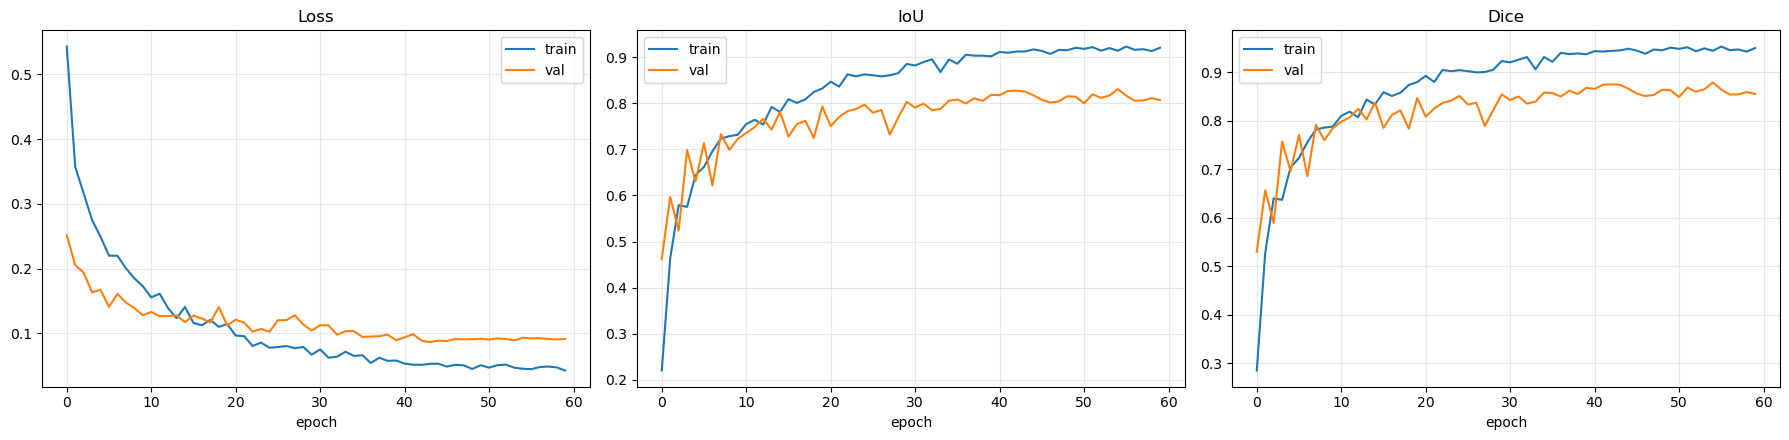

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_title("Loss");  axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_iou"], label="train")
axes[1].plot(history["val_iou"],   label="val")
axes[1].set_title("IoU");   axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history["train_dice"], label="train")
axes[2].plot(history["val_dice"],   label="val")
axes[2].set_title("Dice");  axes[2].set_xlabel("epoch"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## Cell 11 — Visual sanity check on validation samples

Loaded best model from epoch 55  (val IoU=0.8305)


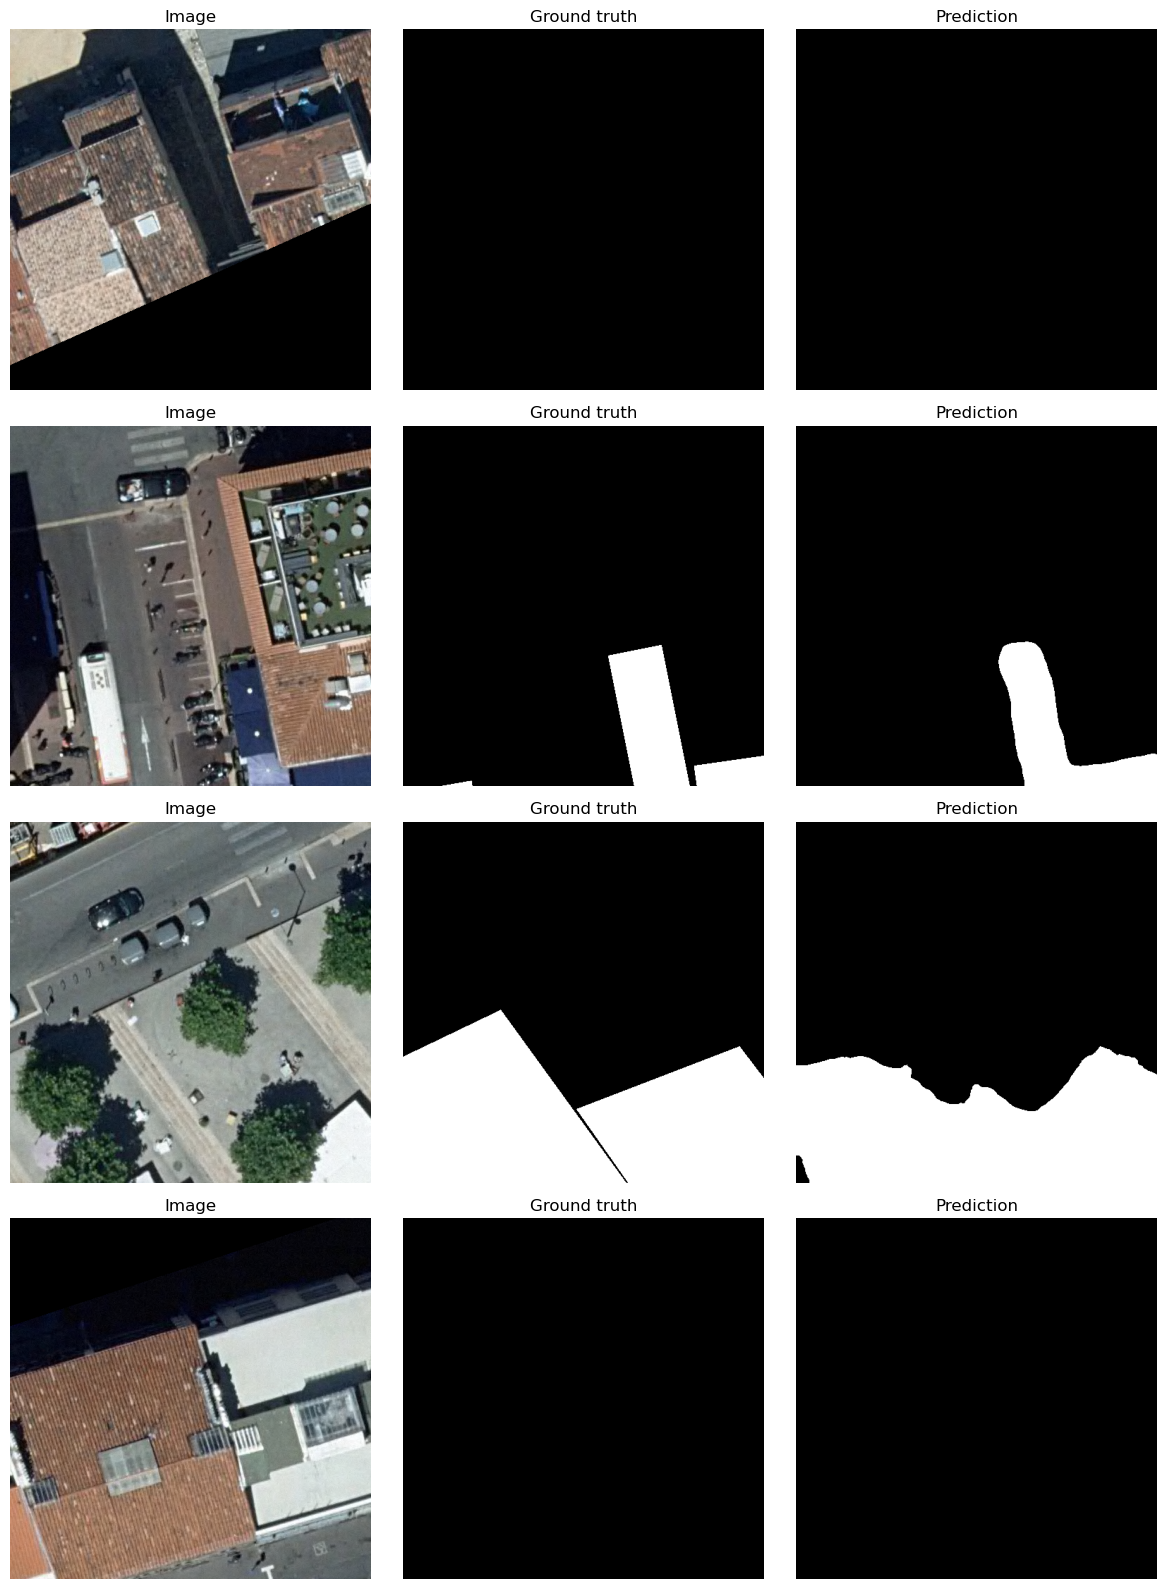

In [15]:
@torch.no_grad()
def show_predictions(model, dataset, n: int = 4, threshold: float = 0.5):
    model.eval()
    idxs = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(len(idxs), 3, figsize=(12, 4 * len(idxs)))
    if len(idxs) == 1:
        axes = axes[None, :]

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    for row, i in enumerate(idxs):
        img, mask = dataset[i]
        x = img.unsqueeze(0).to(DEVICE)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(x)
        pred = (torch.sigmoid(logits[0, 0]).cpu() > threshold).numpy()

        img_show = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

        axes[row, 0].imshow(img_show);                   axes[row, 0].set_title("Image"); axes[row, 0].axis("off")
        axes[row, 1].imshow(mask[0].numpy(), cmap="gray"); axes[row, 1].set_title("Ground truth"); axes[row, 1].axis("off")
        axes[row, 2].imshow(pred,            cmap="gray"); axes[row, 2].set_title("Prediction"); axes[row, 2].axis("off")

    plt.tight_layout(); plt.show()


# Load best weights for visualization
ckpt = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best model from epoch {ckpt['epoch']}  (val IoU={ckpt['val_iou']:.4f})")

show_predictions(model, val_ds, n=4, threshold=THRESHOLD)

## Cell 12 — Inference on unseen `.tif` tiles
Returns a binary mask, Geo-metadata (CRS, transform) is preserved from the input tile so the predicted mask lines up perfectly in QGIS.

In [17]:
from rasterio.errors import RasterioIOError


@torch.no_grad()
def predict_tile(model, tile_path: str, device, threshold: float = 0.5):
    """Run inference on one .tif tile -> (binary_mask uint8 HxW, geo-metadata)."""
    model.eval()

    with rasterio.open(tile_path) as src:
        raw  = src.read()
        meta = src.meta.copy()

    img = prepare_image(raw)                          # (H, W, 3) uint8
    tfm = val_transform()
    tensor = tfm(image=img, mask=np.zeros(img.shape[:2], dtype=np.float32))["image"]
    tensor = tensor.unsqueeze(0).to(device)

    with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
        logits = model(tensor)
    binary = (torch.sigmoid(logits)[0, 0].cpu().numpy() > threshold).astype(np.uint8)

    return binary, meta


def predict_folder(model, in_dir: str, out_dir: str, device,
                   threshold: float = 0.5, name_prefix: str = "pred_"):
    """Predict every .tif in in_dir; write geo-referenced binary masks to out_dir.
    Corrupt or unreadable tiles are skipped and reported at the end."""
    os.makedirs(out_dir, exist_ok=True)
    files = sorted(glob(os.path.join(in_dir, "*.tif")))
    if not files:
        print(f"No .tif files found in {in_dir}")
        return

    failed = []
    written = 0
    for tile_path in tqdm(files, desc="Predicting"):
        try:
            binary, meta = predict_tile(model, tile_path, device, threshold)
        except (RasterioIOError, Exception) as e:
            failed.append((os.path.basename(tile_path), str(e).splitlines()[0]))
            continue

        meta.update({"count": 1, "dtype": "uint8", "nodata": None,
                     "compress": "lzw"})

        out_name = name_prefix + os.path.basename(tile_path)
        out_path = os.path.join(out_dir, out_name)
        try:
            with rasterio.open(out_path, "w", **meta) as dst:
                dst.write(binary, 1)
            written += 1
        except Exception as e:
            failed.append((os.path.basename(tile_path), f"write failed: {str(e).splitlines()[0]}"))

    print(f"\nWrote {written}/{len(files)} predicted masks to {out_dir}")
    if failed:
        print(f"\n{len(failed)} file(s) failed:")
        for name, msg in failed:
            print(f"  - {name}: {msg}")


def find_corrupt_tiles(folder: str):
    """Scan a folder and report tiles that cannot be fully read.
    Use this before predict_folder to identify problematic files in advance."""
    files = sorted(glob(os.path.join(folder, "*.tif")))
    bad = []
    for path in tqdm(files, desc="Checking tiles"):
        try:
            with rasterio.open(path) as src:
                _ = src.read()   # full decode — catches strip-level corruption
        except Exception as e:
            bad.append((os.path.basename(path), str(e).splitlines()[0]))

    print(f"\n{len(bad)}/{len(files)} corrupt or unreadable files:")
    for name, msg in bad:
        print(f"  - {name}: {msg}")
    return bad


# ---- Run inference ----
# Make sure the best checkpoint is loaded (Cell 11 already does this; safe to re-run):
ckpt = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.to(DEVICE)

# (Optional) Pre-scan to identify corrupt tiles before predicting:
# bad_files = find_corrupt_tiles(UNSEEN_TILES_DIR)

# Whole-folder prediction (skips corrupt files automatically):
predict_folder(model, UNSEEN_TILES_DIR, PREDICTIONS_DIR, DEVICE, threshold=THRESHOLD)

Predicting:   0%|          | 0/2439 [00:00<?, ?it/s]


Wrote 1348/2439 predicted masks to segformer_prediction

1091 file(s) failed:
  - marseille_1_test_003_020.tif: Read failed. See previous exception for details.
  - marseille_1_test_003_023.tif: Read failed. See previous exception for details.
  - marseille_1_test_003_024.tif: Read failed. See previous exception for details.
  - marseille_1_test_003_026.tif: Read failed. See previous exception for details.
  - marseille_1_test_003_027.tif: Read failed. See previous exception for details.
  - marseille_1_test_003_028.tif: Read failed. See previous exception for details.
  - marseille_1_test_003_029.tif: Read failed. See previous exception for details.
  - marseille_1_test_003_030.tif: Read failed. See previous exception for details.
  - marseille_1_test_003_031.tif: Read failed. See previous exception for details.
  - marseille_1_test_003_032.tif: Read failed. See previous exception for details.
  - marseille_1_test_003_033.tif: Read failed. See previous exception for details.
  - mars